In [7]:
from consts import *
import pandas as pd
import tiktoken

In [3]:
df = pd.read_csv(DATASET_FILENAME)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7682 entries, 0 to 7681
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   title      7682 non-null   str  
 1   text       7682 non-null   str  
 2   url        7682 non-null   str  
 3   authors    7682 non-null   str  
 4   timestamp  7682 non-null   str  
 5   tags       7682 non-null   str  
dtypes: str(6)
memory usage: 360.2 KB


In [8]:
enc = tiktoken.get_encoding("cl100k_base")
stats = pd.Series([len(enc.encode(t)) for t in df["text"]]).agg(["min", "max", "mean"])

print(stats)

min       280.000000
max     26253.000000
mean     1367.346524
dtype: float64


In [10]:
1367.346524 / 512

2.6705986796875

count     7682.000000
mean      1367.346524
std       1145.121606
min        280.000000
50%       1105.000000
75%       1678.750000
90%       2496.900000
95%       3178.750000
max      26253.000000
dtype: float64


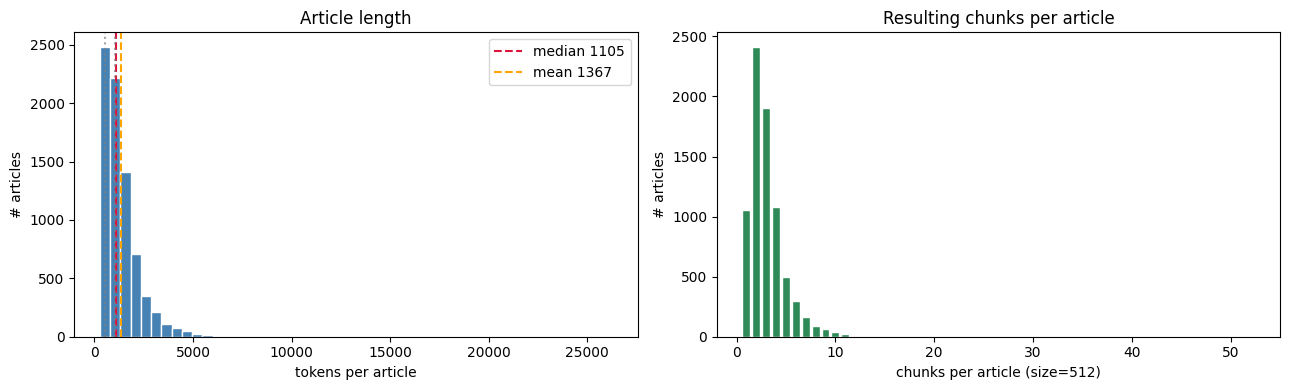

In [13]:
import tiktoken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

enc = tiktoken.get_encoding("cl100k_base")

# str() guards against NaN/float cells — those will crash enc.encode on the full corpus
token_counts = pd.Series([len(enc.encode(str(t))) for t in df["text"].fillna("")])

print(token_counts.describe(percentiles=[0.5, 0.75, 0.9, 0.95]))

CHUNK_SIZE = 512
chunks_per_doc = np.ceil(token_counts / CHUNK_SIZE).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(token_counts, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(token_counts.median(), color="crimson", ls="--", label=f"median {token_counts.median():.0f}")
axes[0].axvline(token_counts.mean(),   color="orange",  ls="--", label=f"mean {token_counts.mean():.0f}")
for b in (512, 1024):
    axes[0].axvline(b, color="gray", ls=":", alpha=0.7)
axes[0].set(xlabel="tokens per article", ylabel="# articles", title="Article length")
axes[0].legend()

vc = chunks_per_doc.value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color="seagreen", edgecolor="white")
axes[1].set(xlabel=f"chunks per article (size={CHUNK_SIZE})", ylabel="# articles",
            title="Resulting chunks per article")

plt.tight_layout()
plt.show()

In [3]:
df.head(1)

,title,text,url,authors,timestamp,tags
0,Mental Note Vol. 24,Photo by Josh Riemer on Unsplash\n\nMerry Chri...,https://medium.com/invisible-illness/mental-no...,['Ryan Fan'],2020-12-26 03:38:10.479000+00:00,"['Mental Health', 'Health', 'Psychology', 'Sci..."


In [7]:
df.head(10).to_csv(SUBSET_DATASET_FILENAME, index=False)